# 📈 Notebook 3.2 — Transformaciones Logarítmica, Box-Cox y Yeo-Johnson
## Diplomado en Ciencia Actuarial y Analítica de Seguros

**Objetivo:** Aprender a tratar distribuciones asimétricas típicas en seguros.  
**Contexto:** Los montos de siniestros en seguros de auto, vida y salud suelen ser muy asimétricos.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import boxcox, yeojohnson
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')
print("✅ Librerías cargadas")


✅ Librerías cargadas


In [2]:
# Generar datos de siniestros (distribución muy asimétrica — log-normal)
np.random.seed(42)
n = 1000

montos_siniestros = np.random.lognormal(mean=9.5, sigma=1.2, size=n)  # Típico en seguros de auto
primas = np.random.lognormal(mean=9.8, sigma=0.6, size=n).clip(5000, 200000)
cambio_reservas = np.random.normal(0, 50000, n)  # Puede ser negativo

df = pd.DataFrame({
    'monto_siniestro': montos_siniestros,
    'prima_anual': primas,
    'cambio_reserva': cambio_reservas,
})

print("📊 Estadísticas de siniestros:")
print(f"  Media:    ${df['monto_siniestro'].mean():>12,.0f}")
print(f"  Mediana:  ${df['monto_siniestro'].median():>12,.0f}")
print(f"  Máximo:   ${df['monto_siniestro'].max():>12,.0f}")
print(f"  Asimetría: {df['monto_siniestro'].skew():.4f} (ideal: cercano a 0)")
print("\n💡 Asimetría > 1 indica distribución muy sesgada a la derecha")


📊 Estadísticas de siniestros:
  Media:    $      28,358
  Mediana:  $      13,772
  Máximo:   $   1,360,384
  Asimetría: 12.7824 (ideal: cercano a 0)

💡 Asimetría > 1 indica distribución muy sesgada a la derecha


## 1. Transformación Logarítmica

**Fórmula:** `Y' = log(Y + 1)`  
La más simple e intuitiva. Perfecta para montos de siniestros (siempre positivos).


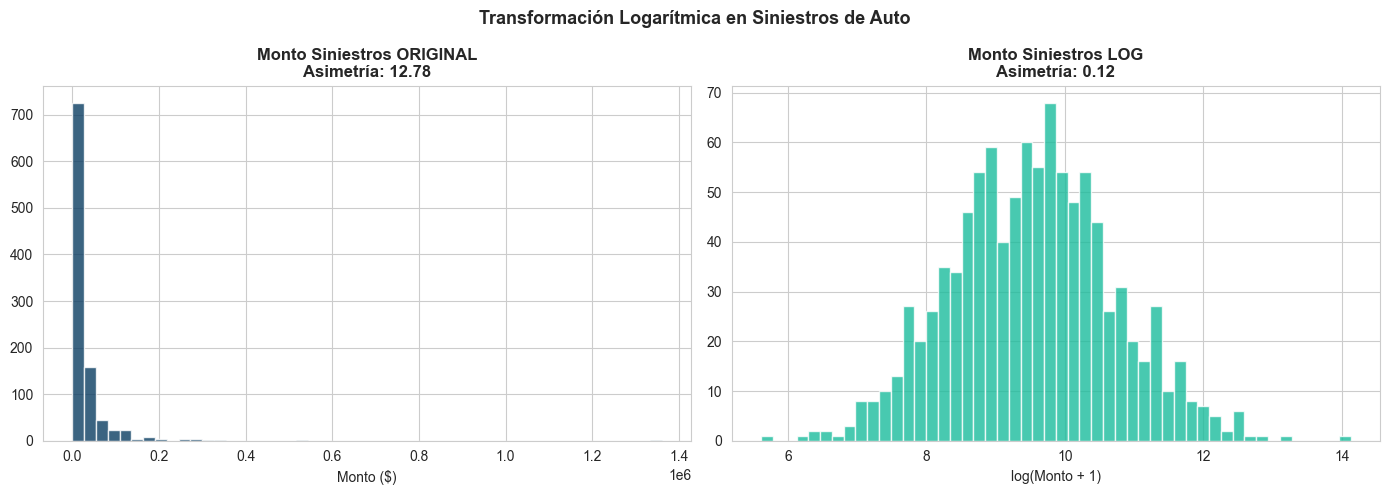


✅ La asimetría bajó de 12.78 a 0.12

🔄 Para recuperar el valor original: valor_original = exp(log_valor) - 1
   Ejemplo: log_valor = 10.0961 → original = $24,247


In [3]:
# Aplicar transformación logarítmica
df['log_siniestro'] = np.log1p(df['monto_siniestro'])  # log(Y + 1) — equivalente a log1p

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['monto_siniestro'], bins=50, color='#0A3D62', alpha=0.8, edgecolor='white')
axes[0].set_title(f'Monto Siniestros ORIGINAL\nAsimetría: {df["monto_siniestro"].skew():.2f}', fontweight='bold')
axes[0].set_xlabel('Monto ($)')

axes[1].hist(df['log_siniestro'], bins=50, color='#1ABC9C', alpha=0.8, edgecolor='white')
axes[1].set_title(f'Monto Siniestros LOG\nAsimetría: {df["log_siniestro"].skew():.2f}', fontweight='bold')
axes[1].set_xlabel('log(Monto + 1)')

plt.suptitle('Transformación Logarítmica en Siniestros de Auto', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('log_transform.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\n✅ La asimetría bajó de {df['monto_siniestro'].skew():.2f} a {df['log_siniestro'].skew():.2f}")
print("\n🔄 Para recuperar el valor original: valor_original = exp(log_valor) - 1")
print(f"   Ejemplo: log_valor = {df['log_siniestro'].iloc[0]:.4f} → original = ${np.expm1(df['log_siniestro'].iloc[0]):,.0f}")


## 2. Transformación Box-Cox

**Fórmula:** `Y^(λ) = (Y^λ − 1)/λ` si λ≠0, `log(Y)` si λ=0  

El parámetro λ se **estima automáticamente** para maximizar la normalidad.  
⚠️ Solo funciona con valores **estrictamente positivos** (Y > 0).


🎯 Lambda óptimo encontrado: λ = -0.0326

¿Qué significa?
  → λ ≈ 0: equivale a transformación logarítmica


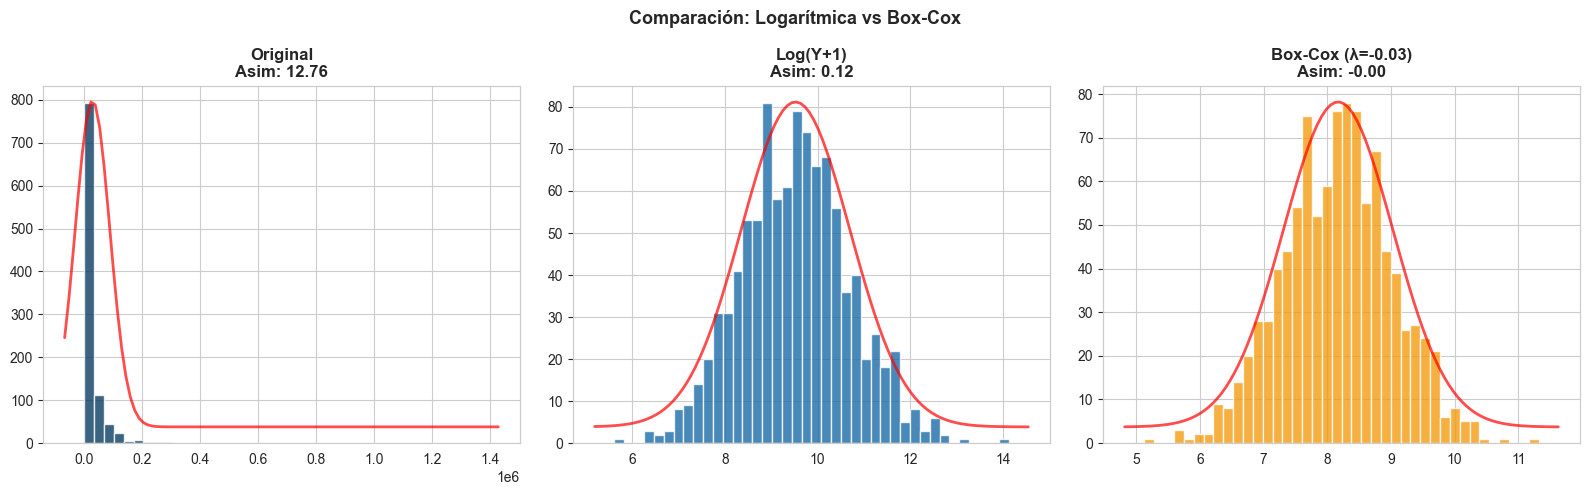

In [4]:
# Aplicar Box-Cox (requiere valores > 0)
y = df['monto_siniestro'].values
y_boxcox, lambda_optimo = boxcox(y)

print(f"🎯 Lambda óptimo encontrado: λ = {lambda_optimo:.4f}")
print(f"\n¿Qué significa?")
if abs(lambda_optimo) < 0.1:
    print("  → λ ≈ 0: equivale a transformación logarítmica")
elif abs(lambda_optimo - 0.5) < 0.1:
    print("  → λ ≈ 0.5: equivale a raíz cuadrada")
elif abs(lambda_optimo - 1) < 0.1:
    print("  → λ ≈ 1: sin transformación significativa")
else:
    print(f"  → Transformación potencial con exponente {lambda_optimo:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
datos = [y, np.log1p(y), y_boxcox]
labels = [f'Original\nAsim: {stats.skew(y):.2f}',
          f'Log(Y+1)\nAsim: {stats.skew(np.log1p(y)):.2f}',
          f'Box-Cox (λ={lambda_optimo:.2f})\nAsim: {stats.skew(y_boxcox):.2f}']
colors = ['#0A3D62', '#1B6CA8', '#F39C12']

for ax, d, lab, c in zip(axes, datos, labels, colors):
    ax.hist(d, bins=40, color=c, alpha=0.8, edgecolor='white')
    ax.set_title(lab, fontweight='bold')
    # Agregar curva normal teórica
    xmin, xmax = ax.get_xlim()
    x_norm = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x_norm, d.mean(), d.std())
    ax_twin = ax.twinx()
    ax_twin.plot(x_norm, p, 'r-', linewidth=2, alpha=0.7, label='Normal')
    ax_twin.set_ylabel('')
    ax_twin.set_yticks([])

plt.suptitle('Comparación: Logarítmica vs Box-Cox', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxcox_transform.png', dpi=120, bbox_inches='tight')
plt.show()


## 3. Transformación Yeo-Johnson

La más versátil: acepta valores **negativos, cero y positivos**.  
Ideal para variables como:
- Cambio en reservas (puede ser positivo o negativo)
- Retorno de inversión
- Diferencia entre prima cobrada y siniestro pagado


📊 Datos de cambio en reservas:
  Rango: $-150,976 a $196,312
  Incluye negativos: 500 registros (50.0%)

🎯 Lambda Yeo-Johnson óptimo: λ = 0.9987


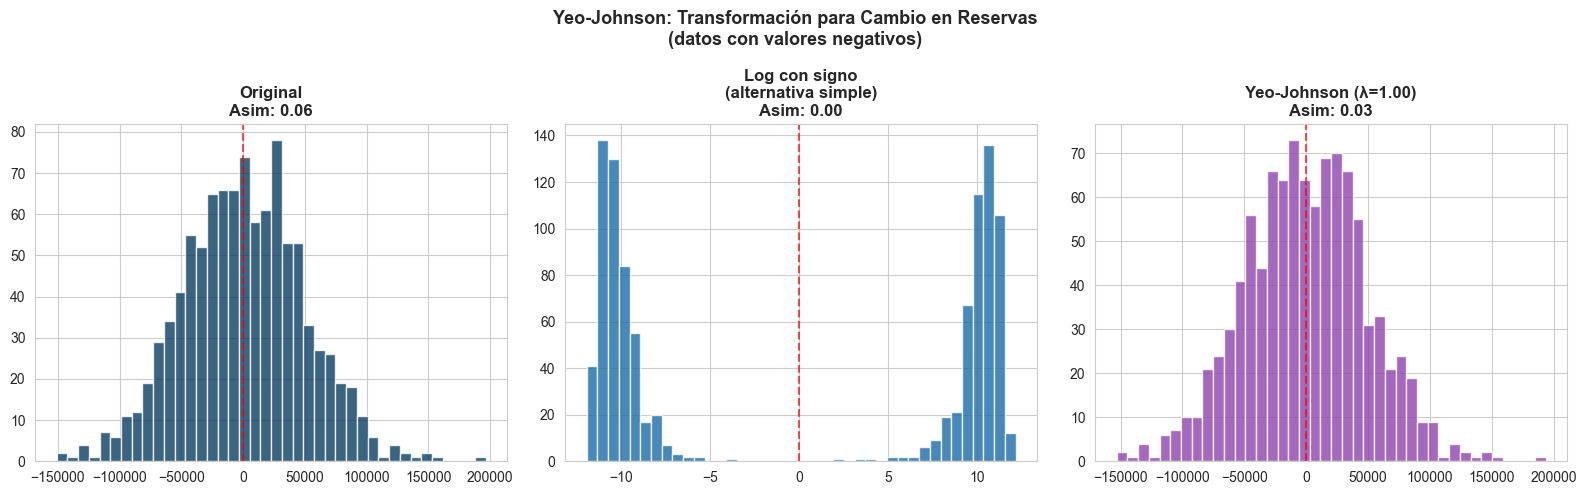

In [5]:
# Aplicar Yeo-Johnson (funciona con valores negativos)
y_negativo = df['cambio_reserva'].values  # Puede ser negativo

# Yeo-Johnson
y_yj, lambda_yj = yeojohnson(y_negativo)
y_log_abs = np.sign(y_negativo) * np.log1p(np.abs(y_negativo))  # Alternativa manual

print(f"📊 Datos de cambio en reservas:")
print(f"  Rango: ${y_negativo.min():,.0f} a ${y_negativo.max():,.0f}")
print(f"  Incluye negativos: {(y_negativo < 0).sum()} registros ({(y_negativo < 0).mean()*100:.1f}%)")
print(f"\n🎯 Lambda Yeo-Johnson óptimo: λ = {lambda_yj:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
datos_plot = [
    (y_negativo, 'Original', '#0A3D62'),
    (y_log_abs, 'Log con signo\n(alternativa simple)', '#1B6CA8'),
    (y_yj, f'Yeo-Johnson (λ={lambda_yj:.2f})', '#8E44AD'),
]

for ax, (d, lab, c) in zip(axes, datos_plot):
    ax.hist(d, bins=40, color=c, alpha=0.8, edgecolor='white')
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.7)
    ax.set_title(f'{lab}\nAsim: {stats.skew(d):.2f}', fontweight='bold')

plt.suptitle('Yeo-Johnson: Transformación para Cambio en Reservas\n(datos con valores negativos)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('yeojohnson_transform.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
# Test de normalidad: ¿Cuánto mejoramos?
from scipy.stats import shapiro

variables_test = {
    'Original': df['monto_siniestro'].sample(500),
    'Log(Y+1)': df['log_siniestro'].sample(500),
    'Box-Cox': pd.Series(y_boxcox).sample(500),
}

print("=" * 55)
print("TEST DE NORMALIDAD (Shapiro-Wilk)")
print("H0: Los datos siguen distribución normal")
print("Si p-valor > 0.05 → No rechazamos normalidad")
print("=" * 55)

for nombre, data in variables_test.items():
    stat, p_valor = shapiro(data)
    decision = "✅ Normal" if p_valor > 0.05 else "❌ No normal"
    print(f"{nombre:15s} | Estadístico: {stat:.4f} | p-valor: {p_valor:.6f} | {decision}")

print("\n💡 Tip actuarial: Una distribución más simétrica mejora la")
print("   estimación de parámetros en GLMs y modelos de frecuencia/severidad")


TEST DE NORMALIDAD (Shapiro-Wilk)
H0: Los datos siguen distribución normal
Si p-valor > 0.05 → No rechazamos normalidad
Original        | Estadístico: 0.3511 | p-valor: 0.000000 | ❌ No normal
Log(Y+1)        | Estadístico: 0.9986 | p-valor: 0.623618 | ✅ Normal
Box-Cox         | Estadístico: 0.9994 | p-valor: 0.989122 | ✅ Normal

💡 Tip actuarial: Una distribución más simétrica mejora la
   estimación de parámetros en GLMs y modelos de frecuencia/severidad


In [12]:
# Test de normalidad: ¿Cuánto mejoramos?
from scipy.stats import shapiro

variables_test = {
    'Original': df['cambio_reserva'].sample(1000),
    'Yeo-Johnson': pd.Series(y_yj).sample(1000),
    'Alternativa manual': pd.Series(y_log_abs).sample(1000),
}

print("=" * 55)
print("TEST DE NORMALIDAD (Shapiro-Wilk)")
print("H0: Los datos siguen distribución normal")
print("Si p-valor > 0.05 → No rechazamos normalidad")
print("=" * 55)

for nombre, data in variables_test.items():
    stat, p_valor = shapiro(data)
    decision = "✅ Normal" if p_valor > 0.05 else "❌ No normal"
    print(f"{nombre:15s} | Estadístico: {stat:.4f} | p-valor: {p_valor:.6f} | {decision}")


TEST DE NORMALIDAD (Shapiro-Wilk)
H0: Los datos siguen distribución normal
Si p-valor > 0.05 → No rechazamos normalidad
Original        | Estadístico: 0.9987 | p-valor: 0.717817 | ✅ Normal
Yeo-Johnson     | Estadístico: 0.9988 | p-valor: 0.786004 | ✅ Normal
Alternativa manual | Estadístico: 0.7164 | p-valor: 0.000000 | ❌ No normal
